---
title: Hex grid spatial models
---

The `HexGrid` utility creates a hexagonal grid within a geographic boundary and produces `Property` objects that compose seamlessly with `StateIndexer`. This lets you build spatial phase-type models on irregular geographic shapes—using the same callback-based graph construction as any other phasic model.

In this tutorial, we use a hex grid covering Africa to model the coalescence time of two lineages sampled from separate cells, where lineages migrate between neighboring cells before finding a common ancestor.

In [1]:
from phasic import (
    Graph, HexGrid, StateIndexer, Property
)
import numpy as np
import geopandas as gpd
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import seaborn as sns
from vscodenb import set_vscode_theme
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)
_pytest = "pytest" in sys.modules

## Creating the hex grid

We download the Natural Earth countries shapefile, extract the African continent, and create a hex grid over it. The `hex_size` is in the units of the coordinate reference system (degrees here), so `hex_size=5` gives cells roughly 550 km across at the equator—coarse enough to keep the two-lineage state space tractable.

In [2]:
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)
africa = world[world['CONTINENT'] == 'Africa'].dissolve()

africa_path = '/tmp/africa.shp'
africa.to_file(africa_path)

grid = HexGrid.from_shapefile(africa_path, hex_size=5)

print(f"Grid dimensions: {grid.n_rows} rows × {grid.n_cols} cols")
print(f"Valid cells: {len(grid.valid_cells())}")

Grid dimensions: 11 rows × 9 cols
Valid cells: 38


## Visualizing the grid

We can plot the hex cells overlaid on the African continent to see which cells fall inside the boundary.

<Figure size 640x480 with 0 Axes>

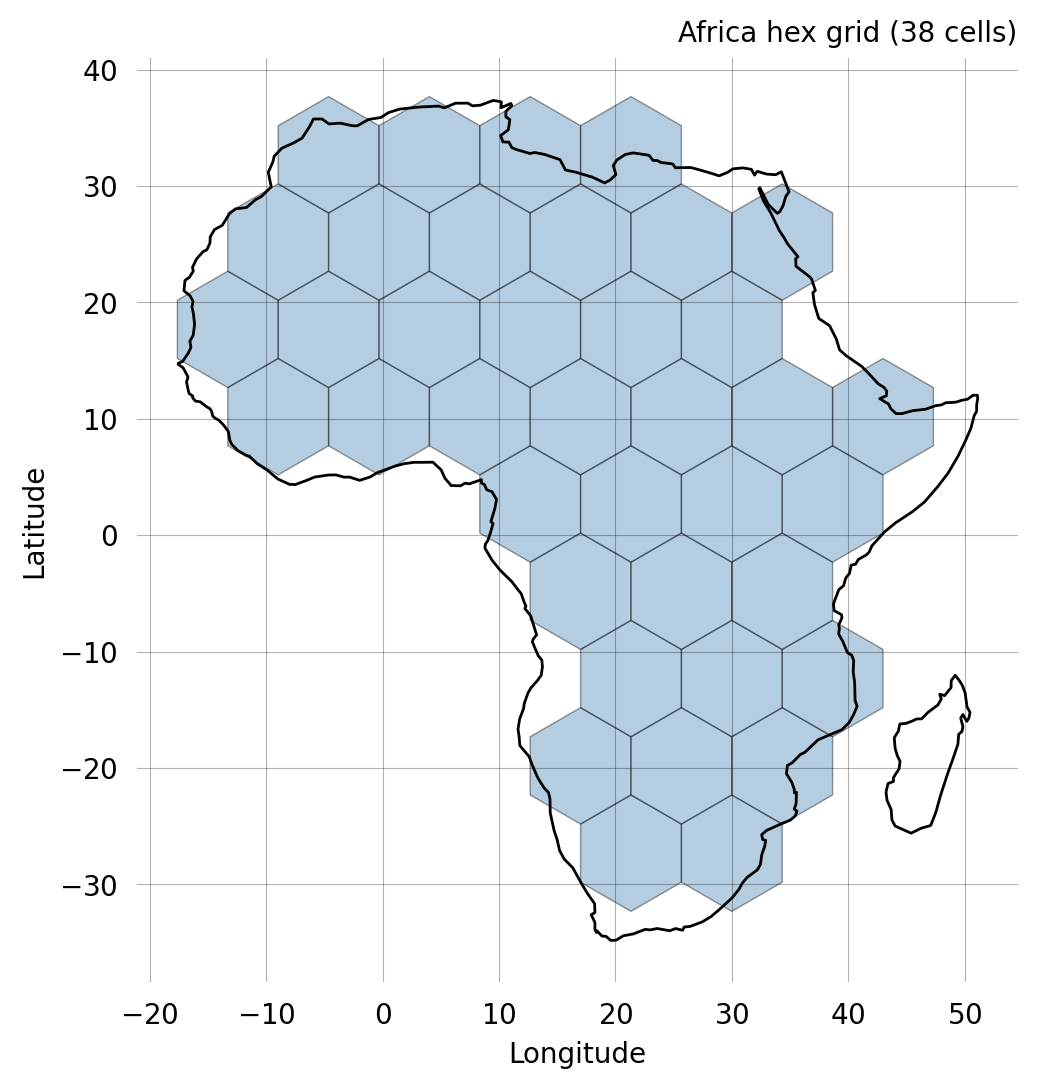

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

africa.boundary.plot(ax=ax, color='black', linewidth=1)

patches = []
for r, c in grid.valid_cells():
    x, y = grid.rowcol_to_coords(r, c)
    patches.append(RegularPolygon(
        (x, y), numVertices=6, radius=grid.hex_size, orientation=0
    ))

pc = PatchCollection(
    patches, facecolor='steelblue', edgecolor='black',
    linewidths=0.5, alpha=0.4
)
ax.add_collection(pc)
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Africa hex grid ({len(grid.valid_cells())} cells)') ;

## Composing grid properties with StateIndexer

`HexGrid.properties()` returns `[row_property, col_property]`—ordinary `Property` objects that can be composed with any other properties in a `StateIndexer`. Here we combine them with a `lineage` property that tracks which of the two sampled lineages occupies a cell.

In [4]:
indexer = StateIndexer(
    cell=grid.properties() + [Property('lineage', min_value=1, max_value=2)]
)

print(f"Properties: {[p.name for p in indexer.cell.properties]}")
print(f"State length: {indexer.state_length}")
print(f"\nExample: index 0 → {indexer.cell.i2p(0)}")

Properties: ['row', 'col', 'lineage']
State length: 198

Example: index 0 → CellProps(row=0, col=0, lineage=1)


## The coalescent model on a hex grid

We model two lineages that migrate between neighboring hex cells and coalesce when they meet in the same cell. The state vector has one entry per `(row, col, lineage)` combination. Each entry is 1 if the lineage is present in that cell, 0 otherwise.

Transitions:

1. **Migration**: Each lineage moves to a neighboring cell at rate $m$.
2. **Coalescence**: When both lineages occupy the same cell, they coalesce at rate $1/(2N)$ (scaled to 1 for convenience).

Since we have exactly two lineages, we track each one separately and the process absorbs when they coalesce.

In [5]:
def spatial_coalescent(state, grid, indexer=None, migration_rate=None):
    """Transition function for two lineages on a hex grid.
    
    State vector: one entry per (row, col, lineage) combination.
    Entry is 1 if that lineage is in that cell, 0 otherwise.
    """
    transitions = []

    # Find positions of each lineage
    pos = {}  # lineage_id -> (row, col)
    for i in range(indexer.cell.state_length):
        if state[i] == 1:
            props = indexer.cell.i2p(i)
            pos[props.lineage] = (props.row, props.col)

    # Need both lineages present
    if len(pos) < 2:
        return transitions

    # Coalescence: if both lineages in same cell
    if pos[1] == pos[2]:
        # Absorb (return empty state)
        child = np.zeros_like(state)
        transitions.append((child, 1.0))  # coalescence rate

    # Migration: each lineage moves to a neighbor
    for lin_id in [1, 2]:
        r, c = pos[lin_id]
        for nr, nc in grid.neighbors(r, c):
            child = state.copy()
            # Remove from current cell
            old_idx = indexer.cell.p2i(row=r, col=c, lineage=lin_id)
            child[old_idx] = 0
            # Place in new cell
            new_idx = indexer.cell.p2i(row=nr, col=nc, lineage=lin_id)
            child[new_idx] = 1
            transitions.append((child, migration_rate))

    return transitions

## Building the graph

We sample lineage 1 from a cell in West Africa and lineage 2 from East Africa, then build the graph. With a coarse grid, this is tractable because the state space is all pairs of cells the two lineages can occupy.

In [6]:
# Sample locations: West Africa (~-5°E, 10°N) and East Africa (~35°E, 0°N)
west_cell = grid.coords_to_rowcol(-5, 10)
east_cell = grid.coords_to_rowcol(35, 0)

print(f"West Africa cell: row={west_cell[0]}, col={west_cell[1]}")
print(f"East Africa cell: row={east_cell[0]}, col={east_cell[1]}")

West Africa cell: row=6, col=1
East Africa cell: row=5, col=6


In [7]:
# Build initial state: lineage 1 in west, lineage 2 in east
initial = np.zeros(indexer.state_length, dtype=int)
initial[indexer.cell.p2i(row=west_cell[0], col=west_cell[1], lineage=1)] = 1
initial[indexer.cell.p2i(row=east_cell[0], col=east_cell[1], lineage=2)] = 1

migration_rate = 1.0

graph = Graph(
    spatial_coalescent,
    ipv=[(initial, 1)],
    grid=grid,
    indexer=indexer,
    migration_rate=migration_rate,
)

print(f"Graph vertices: {graph.vertices_length()}")

Graph vertices: 1446


## Coalescence time distribution

The phase-type distribution of this graph gives us the distribution of coalescence times for two lineages sampled from West and East Africa.

In [8]:
E_T = graph.expectation()
V_T = graph.variance()
print(f"Expected coalescence time: {E_T:.3f}")
print(f"Variance: {V_T:.3f}")
print(f"Std. dev.: {np.sqrt(V_T):.3f}")

Expected coalescence time: 51.340


Variance: 2397.981
Std. dev.: 48.969


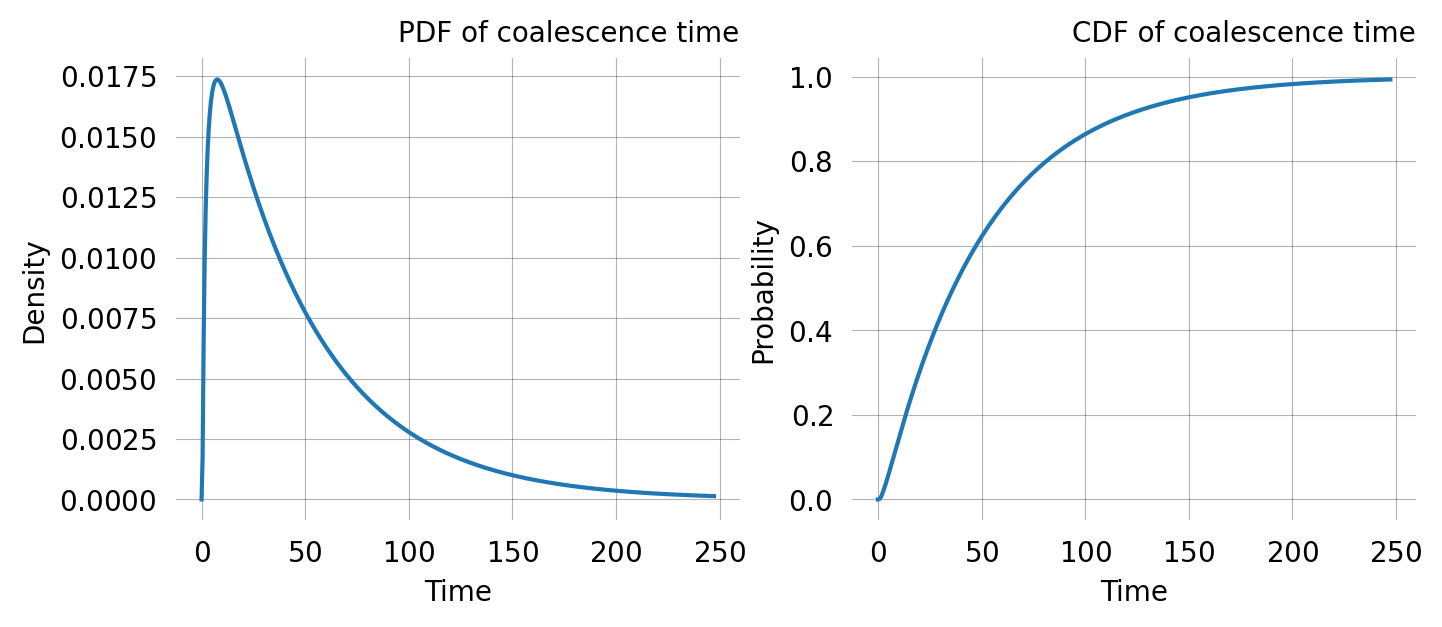

In [9]:
times = np.linspace(0, E_T + 4 * np.sqrt(V_T), 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

ax1.plot(times, graph.pdf(times))
ax1.set_xlabel('Time')
ax1.set_ylabel('Density')
ax1.set_title('PDF of coalescence time')

ax2.plot(times, graph.cdf(times))
ax2.set_xlabel('Time')
ax2.set_ylabel('Probability')
ax2.set_title('CDF of coalescence time') ;

We can verify the PDF against samples from the model:

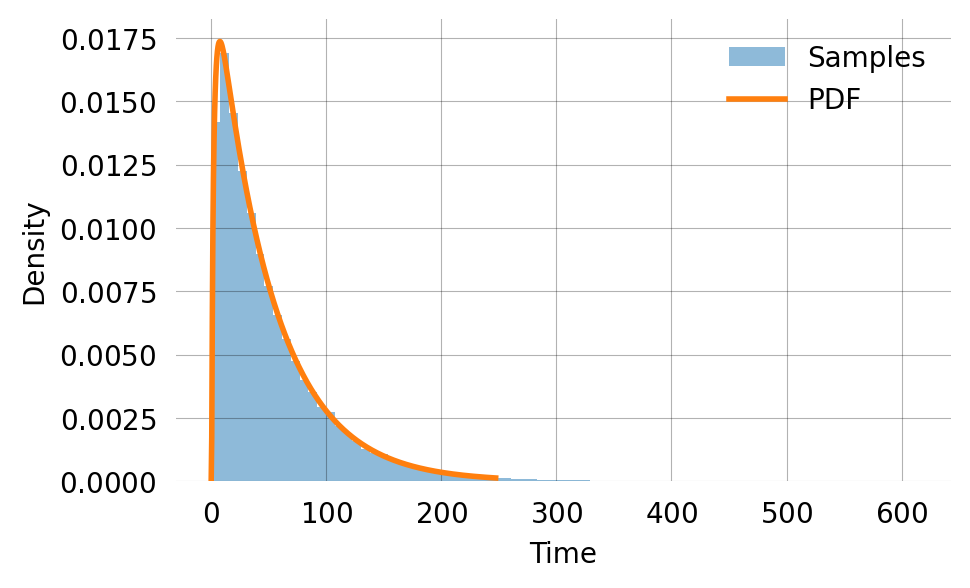

In [10]:
samples = graph.sample(50000)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(samples, bins=80, density=True, alpha=0.5, label='Samples')
ax.plot(times, graph.pdf(times), linewidth=2, label='PDF')
ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.legend() ;

## Visualizing coalescence probability on the grid

We can visualize the probability that the two lineages have coalesced at different cells across the grid by looking at the expected sojourn time in absorbing states per cell. Since each vertex state encodes both lineage positions, we can extract the cell where coalescence occurs (both lineages in the same cell) and map the expected sojourn time to the grid.

In [11]:
# The expected time that probability mass spends in each state
# before absorption gives us a spatial picture of where the 
# lineages spend their time.

# For each state, find the position of lineage 1 and accumulate
# its expected sojourn time on the grid.
sojourn = graph.expected_sojourn_time()

grid_sojourn_lin1 = np.zeros((grid.n_rows, grid.n_cols))
grid_sojourn_lin2 = np.zeros((grid.n_rows, grid.n_cols))

for v_idx in range(1, graph.vertices_length()):  # skip starting vertex
    state = graph.vertex_at(v_idx).state()
    for i in range(indexer.cell.state_length):
        if state[i] == 1:
            props = indexer.cell.i2p(i)
            if props.lineage == 1:
                grid_sojourn_lin1[props.row, props.col] += sojourn[v_idx]
            else:
                grid_sojourn_lin2[props.row, props.col] += sojourn[v_idx]

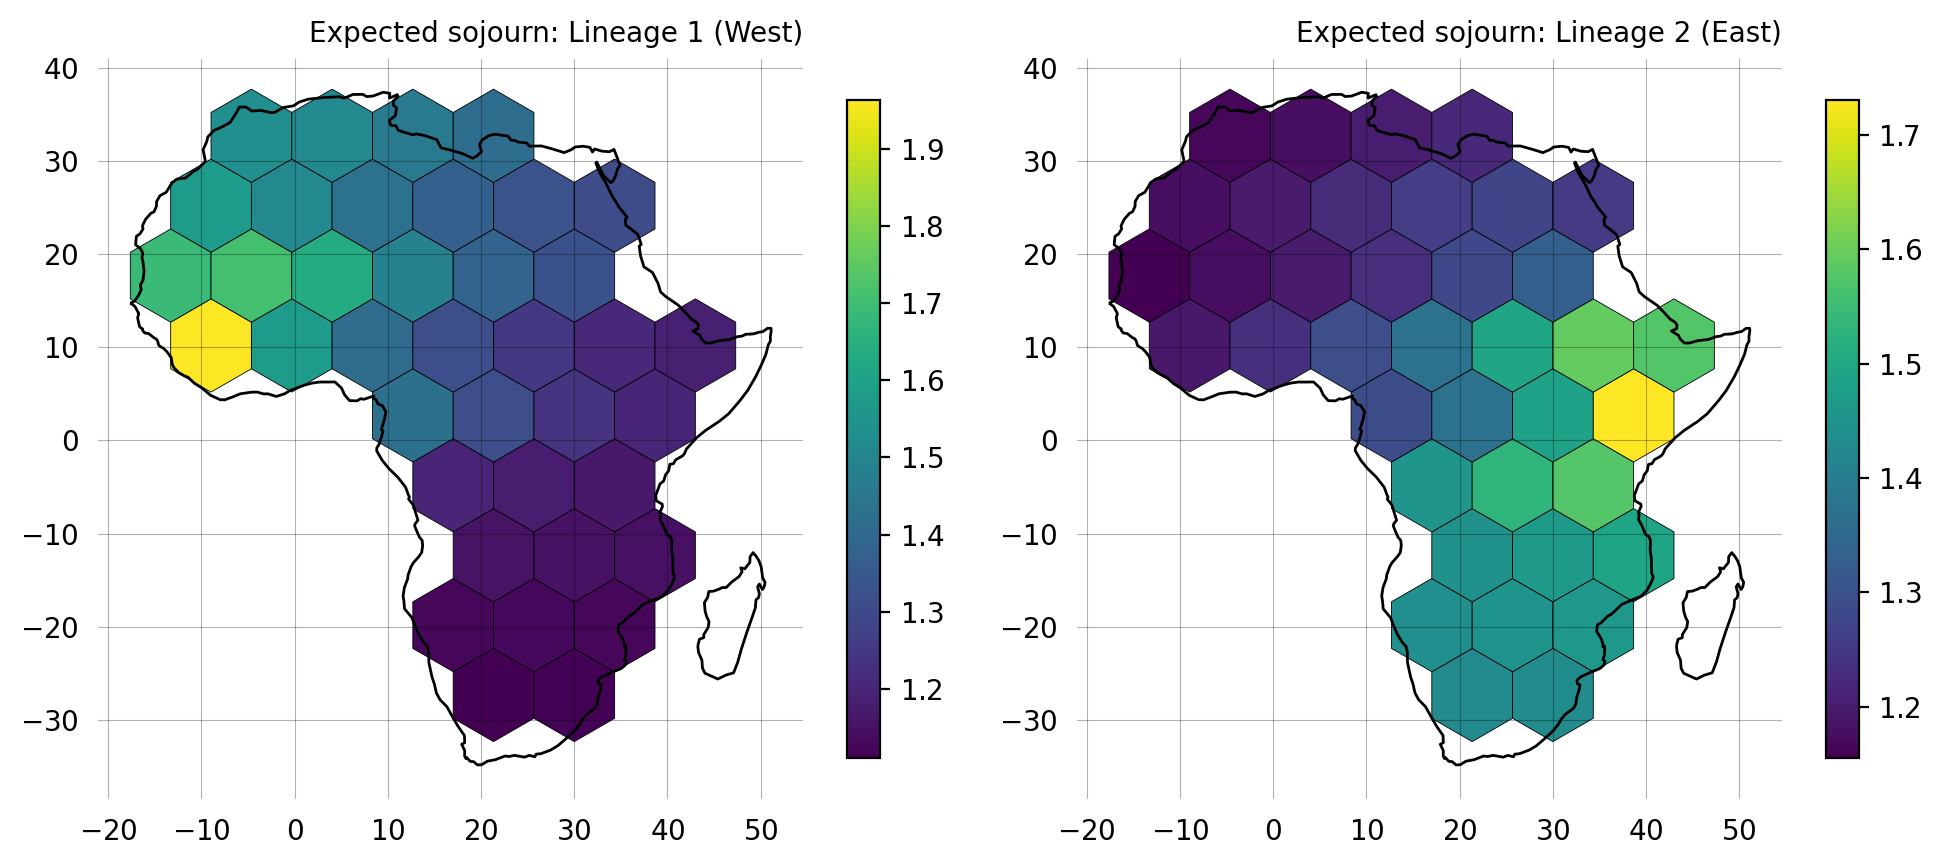

In [12]:
def plot_grid_values(ax, grid, values, title, cmap='viridis'):
    """Plot values on a hex grid."""
    africa.boundary.plot(ax=ax, color='black', linewidth=1)
    
    patches = []
    vals = []
    for r, c in grid.valid_cells():
        x, y = grid.rowcol_to_coords(r, c)
        patches.append(RegularPolygon(
            (x, y), numVertices=6, radius=grid.hex_size, orientation=0
        ))
        vals.append(values[r, c])

    pc = PatchCollection(patches, cmap=cmap, linewidths=0.3, edgecolors='black')
    pc.set_array(np.array(vals))
    ax.add_collection(pc)
    ax.set_aspect('equal')
    ax.set_title(title)
    plt.colorbar(pc, ax=ax, shrink=0.7)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
plot_grid_values(ax1, grid, grid_sojourn_lin1, 'Expected sojourn: Lineage 1 (West)')
plot_grid_values(ax2, grid, grid_sojourn_lin2, 'Expected sojourn: Lineage 2 (East)')
plt.tight_layout() ;

## Effect of migration rate

The migration rate controls how quickly lineages explore the grid. Higher migration rates mean the lineages find each other faster and the expected coalescence time decreases.

In [13]:
migration_rates = [0.2, 0.5, 1.0, 2.0, 5.0]
expectations = []

for m in migration_rates:
    g = Graph(
        spatial_coalescent,
        ipv=[(initial, 1)],
        grid=grid,
        indexer=indexer,
        migration_rate=m,
    )
    expectations.append(g.expectation())
    print(f"m = {m:.1f}: E[T] = {expectations[-1]:.3f}")

m = 0.2: E[T] = 98.667


m = 0.5: E[T] = 63.671


m = 1.0: E[T] = 51.340
m = 2.0: E[T] = 44.866


m = 5.0: E[T] = 40.810


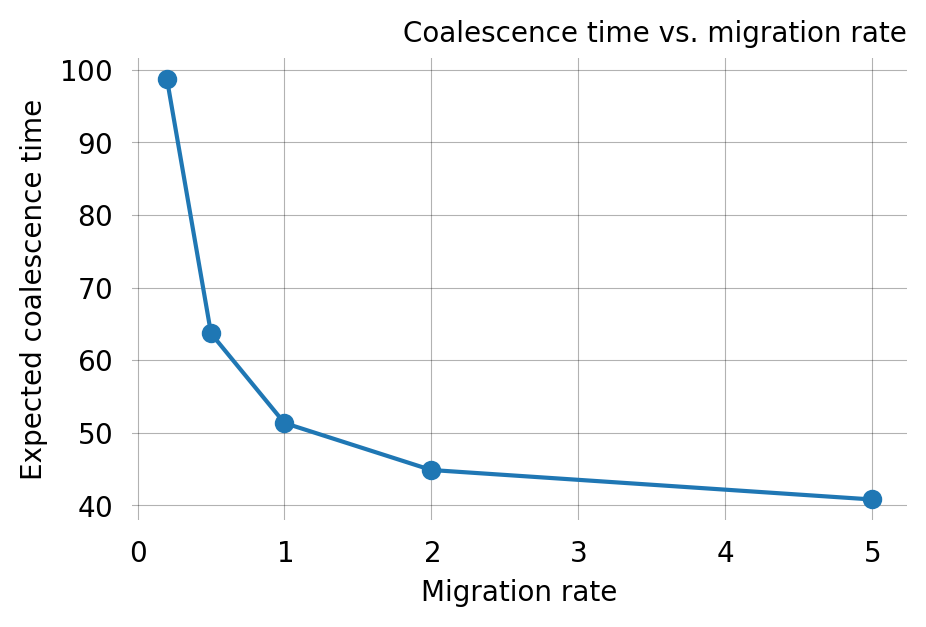

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(migration_rates, expectations, 'o-')
ax.set_xlabel('Migration rate')
ax.set_ylabel('Expected coalescence time')
ax.set_title('Coalescence time vs. migration rate') ;

## Effect of sampling distance

We can also explore how the expected coalescence time depends on the geographic distance between the two sampling locations. We fix lineage 1 in West Africa and vary the position of lineage 2.

In [15]:
# Fix lineage 1 in West Africa, move lineage 2 across a few locations
locations = {
    'Nigeria': (8, 10),
    'Central Africa': (20, 0),
    'East Africa': (35, 0),
    'Southern Africa': (28, -25),
}

migration_rate = 1.0

for name, (lon, lat) in locations.items():
    cell2 = grid.coords_to_rowcol(lon, lat)
    init = np.zeros(indexer.state_length, dtype=int)
    init[indexer.cell.p2i(row=west_cell[0], col=west_cell[1], lineage=1)] = 1
    init[indexer.cell.p2i(row=cell2[0], col=cell2[1], lineage=2)] = 1

    g = Graph(
        spatial_coalescent,
        ipv=[(init, 1)],
        grid=grid,
        indexer=indexer,
        migration_rate=migration_rate,
    )
    print(f"{name:20s} ({lon:3d}°E, {lat:3d}°N): E[T] = {g.expectation():.3f}")

Nigeria              (  8°E,  10°N): E[T] = 47.122
Central Africa       ( 20°E,   0°N): E[T] = 49.087


East Africa          ( 35°E,   0°N): E[T] = 51.340


Southern Africa      ( 28°E, -25°N): E[T] = 53.364


## Comparing PDFs for different sample pairs

Finally, we overlay the coalescence time distributions for the different sampling configurations.

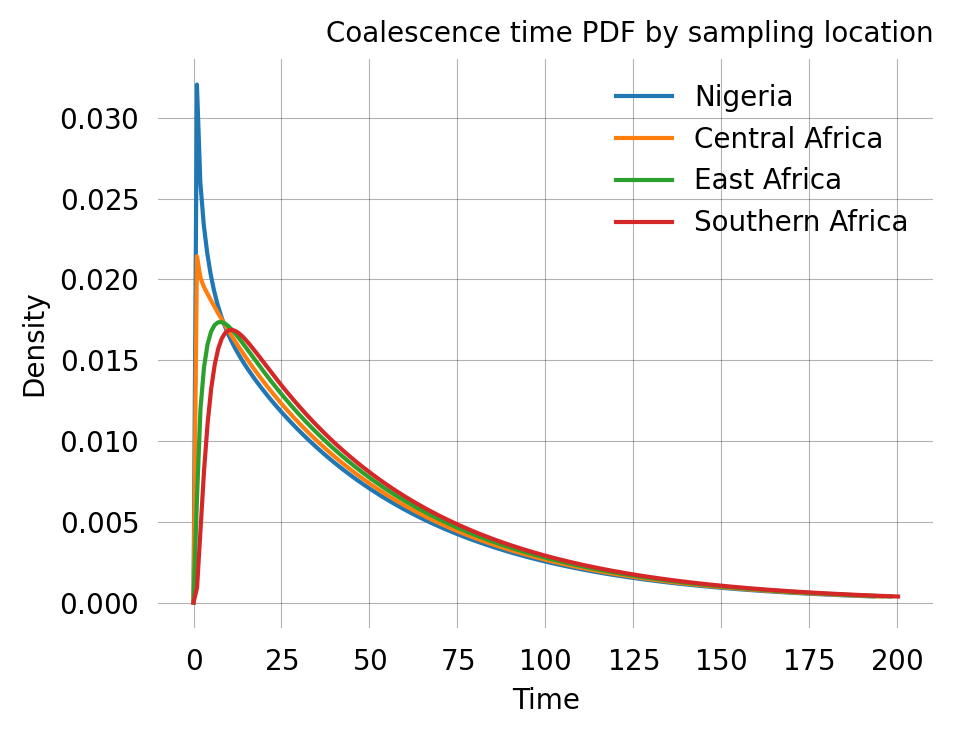

In [16]:
fig, ax = plt.subplots()

for name, (lon, lat) in locations.items():
    cell2 = grid.coords_to_rowcol(lon, lat)
    init = np.zeros(indexer.state_length, dtype=int)
    init[indexer.cell.p2i(row=west_cell[0], col=west_cell[1], lineage=1)] = 1
    init[indexer.cell.p2i(row=cell2[0], col=cell2[1], lineage=2)] = 1

    g = Graph(
        spatial_coalescent,
        ipv=[(init, 1)],
        grid=grid,
        indexer=indexer,
        migration_rate=migration_rate,
    )
    E = g.expectation()
    V = g.variance()
    t = np.linspace(0, E + 3 * np.sqrt(V), 200)
    ax.plot(t, g.pdf(t), label=name)

ax.set_xlabel('Time')
ax.set_ylabel('Density')
ax.set_title('Coalescence time PDF by sampling location')
ax.legend() ;